##Exploring the geographic transferability of AlphaEarth embeddings for crop yield prediction



###Setup and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import os
from pathlib import Path
import json
from shapely.geometry import shape

###Exploratory Data Analysis

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/GEOL0069_Final_Project/Data/US_FM_Corn_Data_shared.csv")

##Separating Data into Source and Domain Regions

In [ ]:
target_crs = 'EPSG:5070' #US Albers Equal Area coord system
midwest_fips = ['17','18','19','20','26','27','29','31','38','39','46','55']

In [ ]:
target_crs = 'EPSG:5070'
base_path = '/content/drive/MyDrive/GEOL0069_Final_Project/Data'
save_path = '/content/drive/MyDrive/GEOL0069_Final_Project/Data/processed_clipped_study_area.gpkg'
midwest_fips = ['17','18','19','20','26','27','29','31','38','39','46','55']

In [ ]:
fips_to_name = {
    '17': 'ILLINOIS', '18': 'INDIANA', '19': 'IOWA', '20': 'KANSAS',
    '26': 'MICHIGAN', '27': 'MINNESOTA', '29': 'MISSOURI', '31': 'NEBRASKA',
    '38': 'NORTH DAKOTA', '39': 'OHIO', '46': 'SOUTH DAKOTA', '55': 'WISCONSIN'
}

In [ ]:
def clean_string(s):
    if pd.isna(s): return ""
    return str(s).upper().replace('.', '').replace("'", "").replace(' ', '').strip()

# load Spatial Data
county_shp_list = list(Path(os.path.join(base_path, 'USA_county_boundaries_2025')).glob("*.shp"))
ecoregion_shp_list = list(Path(os.path.join(base_path, 'USA_ecoregions')).glob("*.shp"))

if not county_shp_list or not ecoregion_shp_list:
    raise FileNotFoundError("Check your directory paths for the county or ecoregion shapefiles.")

counties = gpd.read_file(county_shp_list[0])
ecoregions = gpd.read_file(ecoregion_shp_list[0]).to_crs(target_crs)

# prepare Mapping and Clean Counties
counties['STATE_NAME'] = counties['STATEFP'].map(fips_to_name)
counties['clean_county'] = counties['NAME'].apply(clean_string)

# nuild dictionary for GEOID lookup: (STATE_NAME, CLEAN_COUNTY_NAME) -> GEOID
name_to_geoid = counties.dropna(subset=['STATE_NAME']).set_index(['STATE_NAME', 'clean_county'])['GEOID'].to_dict()

# process CSV Yield Data
csv_files = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in the base_path.")

yield_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# convert to numeric and handle commas
yield_df['yield'] = pd.to_numeric(yield_df['yield'].astype(str).str.replace(',', ''), errors='coerce')

# map State and County names to GEOID
yield_df['GEOID'] = yield_df.apply(
    lambda r: name_to_geoid.get((str(r['State']).upper().strip(), clean_string(r['County']))),
    axis=1
)

# Spatial Join and Aggregation
# Average yield per county
avg_yield = yield_df[yield_df['Geo Level'] == 'COUNTY'].groupby('GEOID')['yield'].mean().reset_index()

# Filter counties to Midwest and merge with yield data
final_gdf = counties[counties['STATEFP'].isin(midwest_fips)].merge(avg_yield, on='GEOID', how='inner').to_crs(target_crs)

# Define Binary Domain based on centroid location
final_gdf['centroid'] = final_gdf.geometry.centroid

# Join with Ecoregions to classify domain
# We use the centroid to ensure each county gets assigned to one primary domain before the cut
assigned = gpd.sjoin(
    final_gdf.set_geometry('centroid'),
    ecoregions[['NA_L1NAME', 'geometry']],
    how='left',
    predicate='within'
)

assigned['Binary_Domain'] = assigned['NA_L1NAME'].apply(
    lambda x: 'GREAT PLAINS' if x == 'GREAT PLAINS' else 'EASTERN TEMPERATE FORESTS'
)

# Restore the original polygon geometry for the final cut
assigned = assigned.set_geometry('geometry')

# perform intersection
# This overlays the county polygons against the ecoregion boundaries
fragments = gpd.overlay(assigned, ecoregions[['NA_L1NAME', 'geometry']], how='intersection')

if 'centroid' in fragments.columns:
    fragments = fragments.drop(columns=['centroid'])

os.makedirs(os.path.dirname(save_path), exist_ok=True)

fragments.to_file(save_path, driver='GPKG')

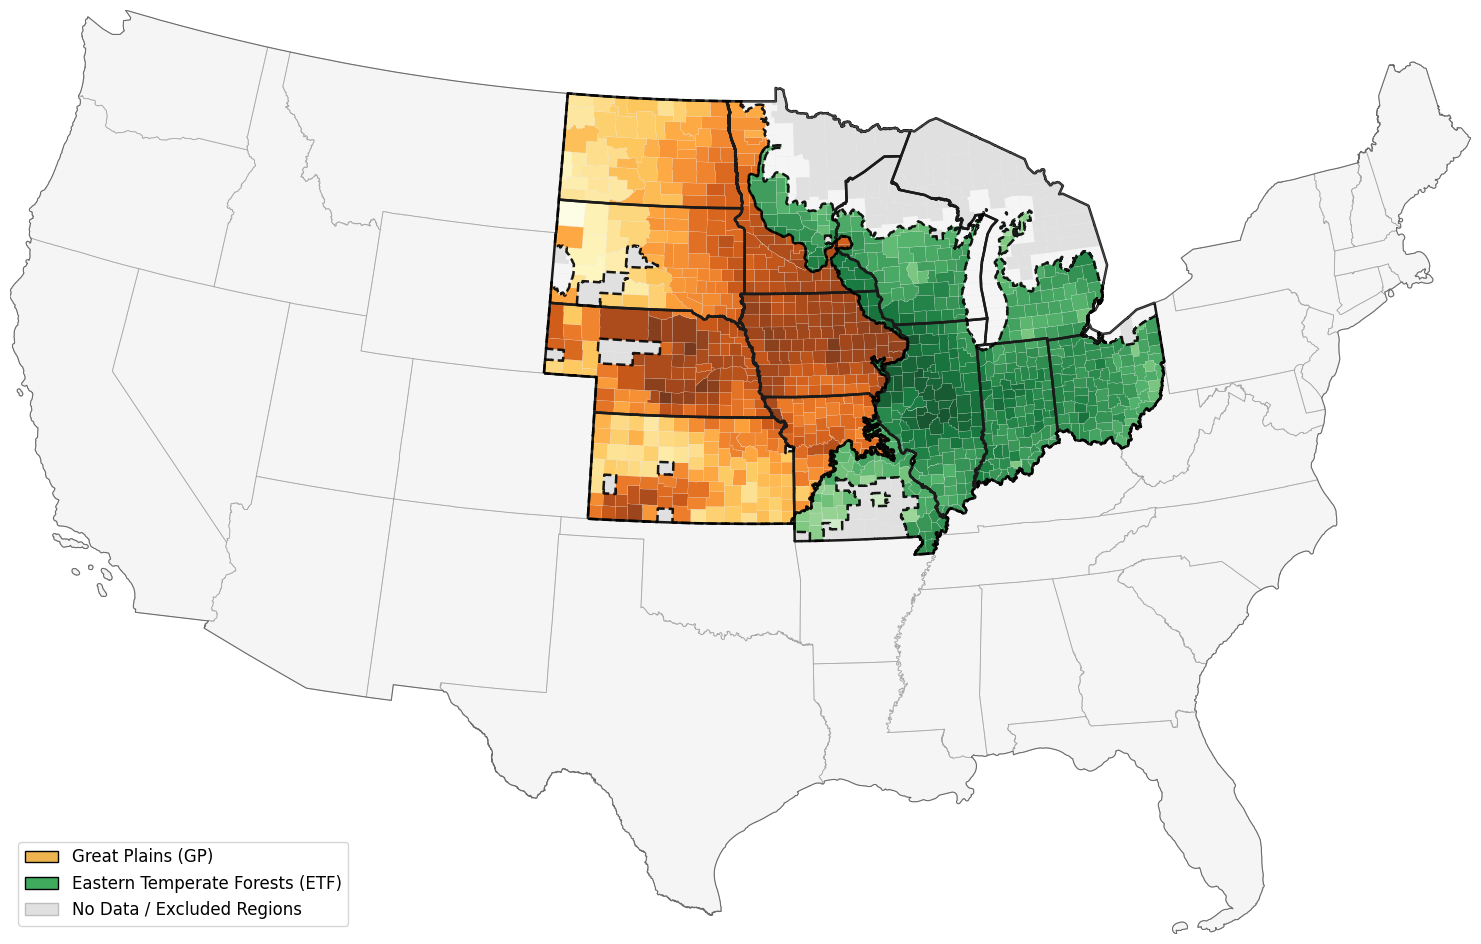

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd

save_path = '/content/drive/MyDrive/GEOL0069_Final_Project/Data/processed_clipped_study_area.gpkg'
final_fragments = gpd.read_file(save_path)

counties_path = '/content/drive/MyDrive/GEOL0069_Final_Project/Data/USA_county_boundaries_2025/tl_2025_us_county.shp'
counties = gpd.read_file(counties_path)

target_crs = 'EPSG:5070'
final_fragments = final_fragments.to_crs(target_crs)

yield_col = 'yield'
eco_col = 'NA_L1NAME_2'

# filtering for the specific domains of interest
final_fragments = final_fragments[final_fragments[eco_col].isin(['GREAT PLAINS', 'EASTERN TEMPERATE FORESTS'])]

# context Layers
midwest_fips = ['17','18','19','20','26','27','29','31','38','39','46','55']
non_conus = ['02', '15', '60', '66', '69', '72', '78']

conus = counties[~counties['STATEFP'].isin(non_conus)].dissolve().to_crs(target_crs)
all_states = counties[~counties['STATEFP'].isin(non_conus)].dissolve(by='STATEFP').to_crs(target_crs)
midwest_full = counties[counties['STATEFP'].isin(midwest_fips)].to_crs(target_crs)

vmin, vmax = final_fragments[yield_col].min(), final_fragments[yield_col].max()
fig, ax = plt.subplots(1, 1, figsize=(20, 12), facecolor='white')

conus.plot(ax=ax, color='#f5f5f5', edgecolor='none')

midwest_full[~midwest_full['GEOID'].isin(final_fragments['GEOID'])].plot(ax=ax, color='#e0e0e0', edgecolor='none')

for reg, cmap in [('GREAT PLAINS', 'YlOrBr'), ('EASTERN TEMPERATE FORESTS', 'Greens')]:
    subset = final_fragments[final_fragments[eco_col] == reg]
    if not subset.empty:
        subset.plot(
            column=yield_col,
            ax=ax,
            cmap=cmap,
            edgecolor='white',
            linewidth=0.1,
            alpha=0.9,
            vmin=vmin,
            vmax=vmax
        )

midwest_full[midwest_full['GEOID'].isin(final_fragments['GEOID'])].boundary.plot(
    ax=ax, color='#bdbdbd', linewidth=0.05, alpha=0.4
)

all_states.boundary.plot(ax=ax, color='#999999', linewidth=0.6, alpha=0.6)
midwest_full.dissolve(by='STATEFP').boundary.plot(ax=ax, color='#1a1a1a', linewidth=1.8, alpha=1.0)
conus.boundary.plot(ax=ax, color='#555555', linewidth=0.8, alpha=0.8)

final_fragments.dissolve(by=eco_col).boundary.plot(
    ax=ax, color='black', linewidth=1.8, linestyle='--', alpha=0.9
)

legend_elements = [
    Patch(facecolor='#eeb44f', edgecolor='black', label='Great Plains (GP)'),
    Patch(facecolor='#41ab5d', edgecolor='black', label='Eastern Temperate Forests (ETF)'),
    Patch(facecolor='#e0e0e0', edgecolor='#bdbdbd', label='No Data / Excluded Regions')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, frameon=True)

ax.set_xlim(conus.total_bounds[0], conus.total_bounds[2])
ax.set_ylim(conus.total_bounds[1], conus.total_bounds[3])
ax.axis('off')

plt.savefig('ETF_GP_Map.png', dpi=300, bbox_inches='tight')
plt.show()

#Further EDA across domains

In [ ]:
# Extract Geometry from JSON
df['geometry'] = df['.geo'].apply(lambda x: shape(json.loads(x)))
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Define Feature Groups
embedding_cols = [f'A{i:02d}' for i in range(64)]
climate_cols = [f'GDD_{i}' for i in range(3, 10)] + [f'ppt_{i}' for i in range(3, 10)]
target_col = 'yield'

stats = {
    "Total Rows": len(gdf),
    "Year Range": f"{gdf['year'].min()} to {gdf['year'].max()}",
    "Unique Counties (FIPS)": gdf['FIPS'].nunique(),
    "Missing Yields": gdf[target_col].isna().sum(),
}

for key, value in stats.items():
    print(f"{key}: {value}")

# Check for any missing values in embeddings or climate data
missing_features = gdf[embedding_cols + climate_cols].isna().sum().sum()
print(f"Missing Feature Values: {missing_features}")

Total Rows: 6325
Year Range: 2017 to 2024
Unique Counties (FIPS): 990
Missing Yields: 0
Missing Feature Values: 0


##Splitting dataframe

In [ ]:
# project ecoregions to match data
target_crs = 'EPSG:5070'
ecoregions = ecoregions.to_crs(target_crs)
gdf = gdf.to_crs(target_crs)

# cntroid-based Join
gdf_centroids = gdf.copy()
gdf_centroids['geometry'] = gdf_centroids.geometry.centroid

# Join only with the ecoregion name column
assigned_obs = gpd.sjoin(
    gdf_centroids,
    ecoregions[['NA_L1NAME', 'geometry']],
    how='left',
    predicate='within'
)

gp_final = assigned_obs[assigned_obs['NA_L1NAME'] == 'GREAT PLAINS'].copy()
etf_final = assigned_obs[assigned_obs['NA_L1NAME'] == 'EASTERN TEMPERATE FORESTS'].copy()

print(f"--- Strict Phase 0 Assignment ---")
print(f"GP Rows: {len(gp_final)} ({gp_final['FIPS'].nunique()} counties)")
print(f"ETF Rows: {len(etf_final)} ({etf_final['FIPS'].nunique()} counties)")

lost = len(gdf) - (len(gp_final) + len(etf_final))
print(f"Dropped observations (Outside GP/ETF): {lost}")

--- Strict Phase 0 Assignment ---
GP Rows: 2974 (485 counties)
ETF Rows: 3093 (456 counties)
Dropped observations (Outside GP/ETF): 258


In [ ]:
outside_data = assigned_obs[~assigned_obs['NA_L1NAME'].isin(['GREAT PLAINS', 'EASTERN TEMPERATE FORESTS'])]

print("--- Ecoregions of the 'Dropped' 258 Observations ---")
print(outside_data['NA_L1NAME'].value_counts(dropna=False))

# checking which states dropped counties belong to
print("\n--- States of Dropped Observations ---")
print(outside_data['State'].value_counts())

--- Ecoregions of the 'Dropped' 258 Observations ---
NA_L1NAME
NORTHERN FORESTS                   256
NORTHWESTERN FORESTED MOUNTAINS      2
Name: count, dtype: int64

--- States of Dropped Observations ---
State
MICHIGAN        130
WISCONSIN        74
MINNESOTA        52
SOUTH DAKOTA      2
Name: count, dtype: int64


In [ ]:
def get_yield_stats(df, name):
    return {
        "Region": name,
        "Mean": df['yield'].mean(),
        "Std Dev": df['yield'].std(),
        "Skewness": df['yield'].skew(),
        "Min": df['yield'].min(),
        "Max": df['yield'].max(),
        "Observations": len(df)
    }

phase0_stats = pd.DataFrame([
    get_yield_stats(gp_final, "Great Plains (GP)"),
    get_yield_stats(etf_final, "Eastern Temp Forests (ETF)")
])

print("--- Table 1: Baseline Yield Statistics ---")
print(phase0_stats)

gap = phase0_stats.loc[1, 'Mean'] - phase0_stats.loc[0, 'Mean']
print(f"\nYield Gap (ETF - GP): {gap:.2f} bu/acre")

--- Table 1: Baseline Yield Statistics ---
                       Region        Mean    Std Dev  Skewness   Min    Max  \
0           Great Plains (GP)  160.472629  42.188696 -0.648002  27.7  240.9   
1  Eastern Temp Forests (ETF)  177.690074  25.926931 -0.460530  70.0  248.2   

   Observations  
0          2974  
1          3093  

Yield Gap (ETF - GP): 17.22 bu/acre


In [ ]:
gp_final['yield_z'] = (gp_final['yield'] - gp_final['yield'].mean()) / gp_final['yield'].std()
etf_final['yield_z'] = (etf_final['yield'] - etf_final['yield'].mean()) / etf_final['yield'].std()

print("Verification:")
print(f"GP Z-Mean: {gp_final['yield_z'].mean():.2f}, Z-Std: {gp_final['yield_z'].std():.2f}")
print(f"ETF Z-Mean: {etf_final['yield_z'].mean():.2f}, Z-Std: {etf_final['yield_z'].std():.2f}")

Verification:
GP Z-Mean: 0.00, Z-Std: 1.00
ETF Z-Mean: -0.00, Z-Std: 1.00


In [ ]:
embedding_cols = [f'A{i:02d}' for i in range(64)]

all_data = pd.concat([gp_final, etf_final])
embedding_vars = all_data[embedding_cols].var()

print("--- Embedding Variance Summary ---")
print(f"Minimum Variance: {embedding_vars.min():.6f}")
print(f"Maximum Variance: {embedding_vars.max():.6f}")
print(f"Ratio (Max/Min): {embedding_vars.max() / embedding_vars.min():.2f}")

# Optional: Identify the outlier dimensions
print("\nTop 5 highest variance dimensions:")
print(embedding_vars.sort_values(ascending=False).head(5))

--- Embedding Variance Summary ---
Minimum Variance: 0.000650
Maximum Variance: 0.006182
Ratio (Max/Min): 9.51

Top 5 highest variance dimensions:
A50    0.006182
A15    0.005389
A48    0.005333
A26    0.004182
A14    0.004131
dtype: float64


##Initial Model Testing

###In-Domain

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

gp_final['yield_tha'] = gp_final['yield'] * 0.0673
etf_final['yield_tha'] = etf_final['yield'] * 0.0673

def run_loyo_cv(data, region_name):
    years = sorted(data['year'].unique())
    results = []

    print(f"--- LOYO CV for {region_name} ---")
    for year in years:
        train = data[data['year'] != year]
        test = data[data['year'] == year]

        X_train, y_train = train[embedding_cols], train['yield_tha']
        X_test, y_test = test[embedding_cols], test['yield_tha']

        rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
        rf.fit(X_train, y_train)

        preds = rf.predict(X_test)
        r2 = r2_score(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        results.append({'year': year, 'R2': r2, 'RMSE': rmse})
        print(f"Year {year}: R2 = {r2:.3f}, RMSE = {rmse:.3f}")

    return pd.DataFrame(results)

gp_results = run_loyo_cv(gp_final, "Great Plains")
etf_results = run_loyo_cv(etf_final, "Eastern Temp Forests")

print("\n--- Summary of In-Domain Replication ---")
print(f"GP Average R2: {gp_results['R2'].mean():.3f}")
print(f"ETF Average R2: {etf_results['R2'].mean():.3f}")

--- LOYO CV for Great Plains ---
Year 2017: R2 = 0.862, RMSE = 1.021
Year 2018: R2 = 0.707, RMSE = 1.457
Year 2019: R2 = 0.809, RMSE = 1.020
Year 2020: R2 = 0.752, RMSE = 1.210
Year 2021: R2 = 0.809, RMSE = 1.468
Year 2022: R2 = 0.781, RMSE = 1.519
Year 2023: R2 = 0.782, RMSE = 1.309
Year 2024: R2 = 0.687, RMSE = 1.507
--- LOYO CV for Eastern Temp Forests ---
Year 2017: R2 = 0.718, RMSE = 0.839
Year 2018: R2 = 0.708, RMSE = 1.043
Year 2019: R2 = 0.492, RMSE = 1.018
Year 2020: R2 = 0.688, RMSE = 0.852
Year 2021: R2 = 0.584, RMSE = 1.024
Year 2022: R2 = 0.709, RMSE = 0.911
Year 2023: R2 = 0.717, RMSE = 0.995
Year 2024: R2 = 0.644, RMSE = 1.132

--- Summary of In-Domain Replication ---
GP Average R2: 0.774
ETF Average R2: 0.657


##Under transfer

In [ ]:
# scale to t/ha
all_data['yield_tha'] = all_data['yield'] * 0.0673

east_states = [17, 18, 26, 39, 55]
west_states = [19, 20, 27, 29, 38, 31, 46]

df_east = all_data[all_data['STATE_FIPS'].isin(east_states)].copy()
df_west = all_data[all_data['STATE_FIPS'].isin(west_states)].copy()

def run_transfer_test(train_df, test_df, source_name, target_name, cols):
    X_train, y_train = train_df[cols], train_df['yield_tha']
    X_test, y_test = test_df[cols], test_df['yield_tha']
  #equivalent RF hyperparams to Ma et al
    rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)

    preds = rf.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    bias = np.mean(preds - y_test)

    return {
        "Transfer Direction": f"{source_name} -> {target_name}",
        "Target R2": round(r2, 4),
        "Target RMSE": round(rmse, 4),
        "Bias (t/ha)": round(bias, 4)
    }

embedding_cols = [f'A{i:02d}' for i in range(64)]
climate_cols = [f'GDD_{i}' for i in range(3, 10)] + [f'ppt_{i}' for i in range(3, 10)]

#embedding-only transfer
res_emb_ew = run_transfer_test(df_east, df_west, "East", "West", cols=embedding_cols)
res_emb_we = run_transfer_test(df_west, df_east, "West", "East", cols=embedding_cols)

#climate-only transfer
res_cli_ew = run_transfer_test(df_east, df_west, "East", "West", cols=climate_cols)
res_cli_we = run_transfer_test(df_west, df_east, "West", "East", cols=climate_cols)

replication_table = pd.DataFrame([
    {"Method": "AEF (Embeddings)", **res_emb_ew},
    {"Method": "AEF (Embeddings)", **res_emb_we},
    {"Method": "Climate Only", **res_cli_ew},
    {"Method": "Climate Only", **res_cli_we}
])

print("--- Phase 0: Table 6 Replication (State-Based) ---")
print(replication_table)

--- Phase 0: Table 6 Replication (State-Based) ---
             Method Transfer Direction  Target R2  Target RMSE  Bias (t/ha)
0  AEF (Embeddings)       East -> West    -0.0894       2.8677       1.7444
1  AEF (Embeddings)       West -> East     0.4976       1.1433      -0.1693
2      Climate Only       East -> West    -0.0721       2.8449       1.2948
3      Climate Only       West -> East    -0.5808       2.0280       0.0812


In [ ]:
print("--- Data Volume Verification ---")
print(f"Total rows in all_data: {len(all_data)}")

print(f"\n[EAST REGION]")
print(f"Rows assigned to East: {len(df_east)}")
print(f"Unique Counties in East: {df_east['STATE_FIPS'].nunique() if 'STATE_FIPS' in df_east else 'N/A'}")

print(f"\n[WEST REGION]")
print(f"Rows assigned to West: {len(df_west)}")
print(f"Unique Counties in West: {df_west['STATE_FIPS'].nunique() if 'STATE_FIPS' in df_west else 'N/A'}")

nan_count = all_data[embedding_cols + climate_cols].isna().any(axis=1).sum()
print(f"\n[DATA INTEGRITY]")
print(f"Rows with missing features (will be ignored by model): {nan_count}")

total_subset = len(df_east) + len(df_west)
if total_subset > 0:
    print(f"East/West Ratio: {len(df_east)/total_subset:.2f} / {len(df_west)/total_subset:.2f}")

--- Data Volume Verification ---
Total rows in all_data: 6067

[EAST REGION]
Rows assigned to East: 2608
Unique Counties in East: 5

[WEST REGION]
Rows assigned to West: 3459
Unique Counties in West: 7

[DATA INTEGRITY]
Rows with missing features (will be ignored by model): 0
East/West Ratio: 0.43 / 0.57


##Diagnostics

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

y_domain_east = np.zeros(len(df_east))
y_domain_west = np.ones(len(df_west))

X_domain = np.vstack([df_east[embedding_cols], df_west[embedding_cols]])
y_domain = np.hstack([y_domain_east, y_domain_west])

domain_clf = LogisticRegression(max_iter=1000)
domain_clf.fit(X_domain, y_domain)

print("--- Phase 1: Domain Discriminability Test ---")
print(classification_report(y_domain, domain_clf.predict(X_domain)))

--- Phase 1: Domain Discriminability Test ---
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95      2608
         1.0       0.97      0.95      0.96      3459

    accuracy                           0.95      6067
   macro avg       0.95      0.95      0.95      6067
weighted avg       0.95      0.95      0.95      6067



In [ ]:
print("East (Source) Yield - Mean: {:.2f}, Std: {:.2f}, Min: {:.2f}, Max: {:.2f}".format(
    df_east['yield_tha'].mean(), df_east['yield_tha'].std(),
    df_east['yield_tha'].min(), df_east['yield_tha'].max()))

print("West (Target) Yield - Mean: {:.2f}, Std: {:.2f}, Min: {:.2f}, Max: {:.2f}".format(
    df_west['yield_tha'].mean(), df_west['yield_tha'].std(),
    df_west['yield_tha'].min(), df_west['yield_tha'].max()))

East (Source) Yield - Mean: 12.13, Std: 1.61, Min: 5.46, Max: 16.70
West (Target) Yield - Mean: 10.83, Std: 2.75, Min: 1.86, Max: 16.21


--- Diagnostic I: Label Space ---
Source samples outside Target yield range: 0.35%


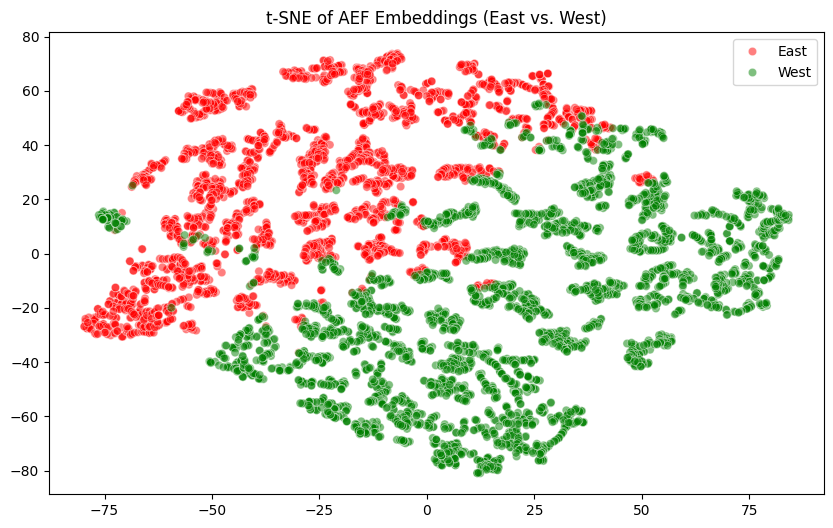


--- Diagnostic III: Generalist Leakage ---
Domain Discriminability using ONLY 16 Generalists: 0.9308
Compare to 64-dim Accuracy: 0.9500


In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

west_min, west_max = df_west['yield_tha'].min(), df_west['yield_tha'].max()
outliers_source = df_east[(df_east['yield_tha'] < west_min) | (df_east['yield_tha'] > west_max)]
percent_outlier = (len(outliers_source) / len(df_east)) * 100

print(f"--- Diagnostic I: Label Space ---")
print(f"Source samples outside Target yield range: {percent_outlier:.2f}%")

X_combined = np.vstack([df_east[embedding_cols], df_west[embedding_cols]])
domains = ['East'] * len(df_east) + ['West'] * len(df_west)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_combined)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=domains, palette={'East': 'red', 'West': 'green'}, alpha=0.5)
plt.title("t-SNE of AEF Embeddings (East vs. West)")
plt.show()

universal_generalists = ['A27', 'A37', 'A05', 'A34', 'A23', 'A62', 'A61', 'A56', 'A19', 'A63', 'A08', 'A43', 'A11', 'A36', 'A16', 'A49']
X_gen = np.vstack([df_east[universal_generalists], df_west[universal_generalists]])

domain_clf_gen = LogisticRegression(max_iter=1000)
domain_clf_gen.fit(X_gen, y_domain) # y_domain from previous test
gen_acc = domain_clf_gen.score(X_gen, y_domain)

print(f"\n--- Diagnostic III: Generalist Leakage ---")
print(f"Domain Discriminability using ONLY 16 Generalists: {gen_acc:.4f}")
print(f"Compare to 64-dim Accuracy: 0.9500")

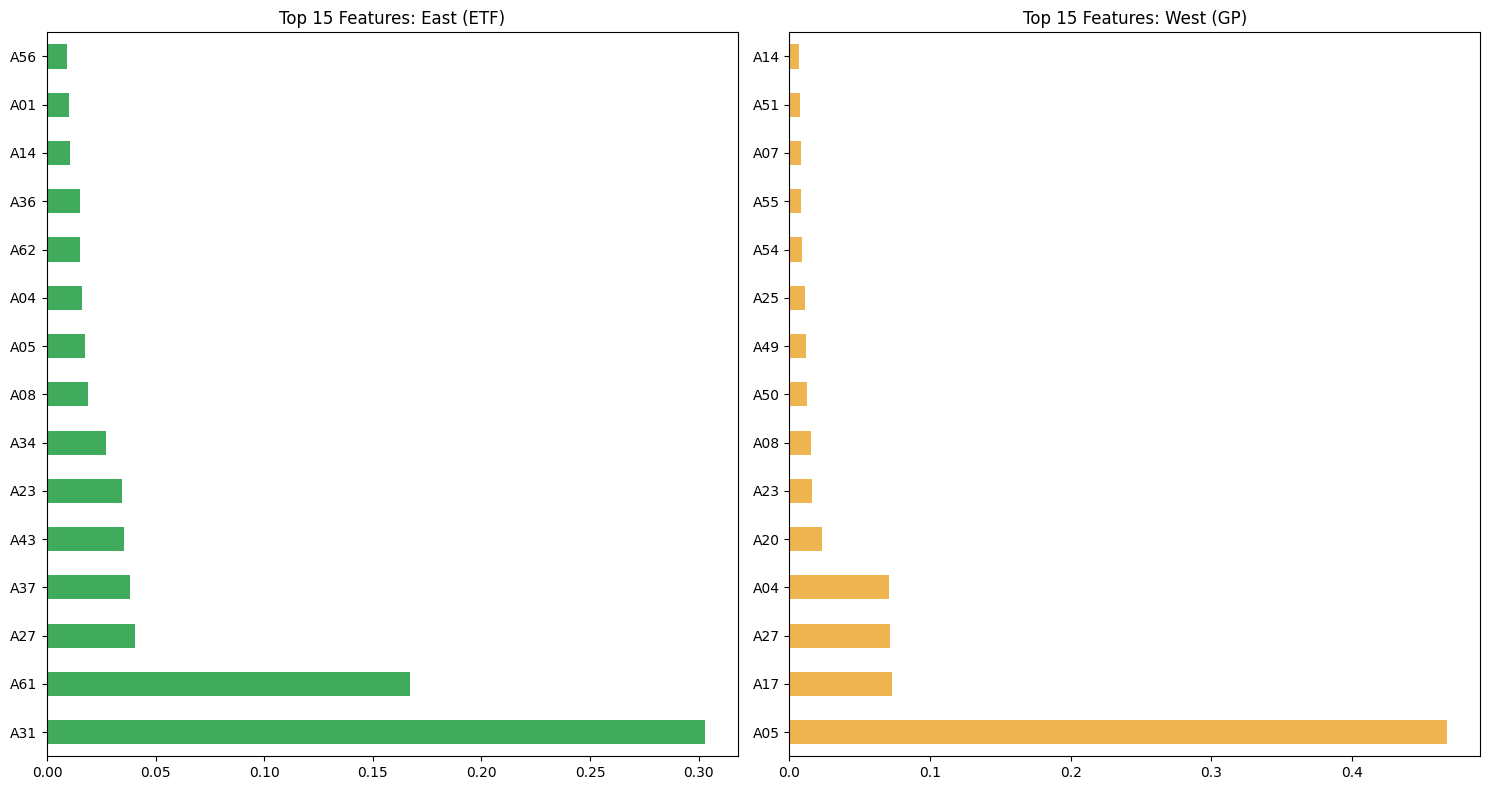

Master Diagnostic Table (Top 10 most unstable by correlation):
     Imp_East  Imp_West  Corr_East  Corr_West  Corr_Diff  Imp_Diff  Sign_Flip
A20  0.002553  0.022860  -0.422578   0.529961   0.952539  0.020307       True
A55  0.007588  0.008343  -0.233398   0.633708   0.867106  0.000755       True
A56  0.008993  0.004545  -0.366523   0.459605   0.826129  0.004448       True
A41  0.004524  0.005940  -0.267620   0.432698   0.700318  0.001415       True
A39  0.003153  0.002705  -0.426229   0.261746   0.687975  0.000447       True
A19  0.008605  0.003131  -0.550839   0.134850   0.685689  0.005474       True
A44  0.008123  0.006212  -0.552315   0.107274   0.659590  0.001912       True
A13  0.002706  0.005164  -0.285505   0.360095   0.645599  0.002458       True
A38  0.003625  0.005894   0.324041  -0.235118   0.559160  0.002269       True
A14  0.010529  0.006968   0.530901  -0.007264   0.538165  0.003561       True


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# feature importance
def get_rf_importance(df, cols, title):
    rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf.fit(df[cols], df['yield_tha'])
    return pd.Series(rf.feature_importances_, index=cols, name=title)

importance_east = get_rf_importance(df_east, embedding_cols, 'Imp_East')
importance_west = get_rf_importance(df_west, embedding_cols, 'Imp_West')

# yield correlation
corr_east = df_east[embedding_cols].corrwith(df_east['yield_tha']).rename('Corr_East')
corr_west = df_west[embedding_cols].corrwith(df_west['yield_tha']).rename('Corr_West')

diag_table = pd.concat([importance_east, importance_west, corr_east, corr_west], axis=1)

# Identify unstable dimensions
diag_table['Corr_Diff'] = (diag_table['Corr_East'] - diag_table['Corr_West']).abs()
diag_table['Imp_Diff'] = (diag_table['Imp_East'] - diag_table['Imp_West']).abs()

# sign flips
diag_table['Sign_Flip'] = np.sign(diag_table['Corr_East']) != np.sign(diag_table['Corr_West'])

# plot feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

diag_table['Imp_East'].sort_values(ascending=False).head(15).plot(kind='barh', ax=ax1, color='#41ab5d')
ax1.set_title("Top 15 Features: East (ETF)")

diag_table['Imp_West'].sort_values(ascending=False).head(15).plot(kind='barh', ax=ax2, color='#eeb44f')
ax2.set_title("Top 15 Features: West (GP)")

plt.tight_layout()
plt.show()

print("Master Diagnostic Table (Top 10 most unstable by correlation):")
print(diag_table.sort_values('Corr_Diff', ascending=False).head(10))

##Correlations

In [ ]:
climate_vars = [f'GDD_{i}' for i in range(5, 10)] + [f'ppt_{i}' for i in range(5, 10)]

# compute correlation matrices for each region
clim_corr_east = df_east[embedding_cols].apply(lambda x: df_east[climate_vars].corrwith(x))
clim_corr_west = df_west[embedding_cols].apply(lambda x: df_west[climate_vars].corrwith(x))

clim_shift = (clim_corr_east - clim_corr_west).abs().mean(axis=0).rename('Climatic_Stability_Score')

diag_table = diag_table.join(clim_shift)

print("--- Phase 1(b): Embedding-Climate Stability ---")
print("Top 5 Dimensions with the most unstable climate relationships:")
print(diag_table.sort_values('Climatic_Stability_Score', ascending=False)['Climatic_Stability_Score'].head(5))

--- Phase 1(b): Embedding-Climate Stability ---
Top 5 Dimensions with the most unstable climate relationships:
A44    0.503192
A21    0.466486
A45    0.392495
A62    0.374117
A61    0.364221
Name: Climatic_Stability_Score, dtype: float64


In [ ]:
from scipy.stats import wasserstein_distance

# compute Wasserstein Distance for all 64 dimensions
w_distances = {}
for col in embedding_cols:
    # Measure distance between the distribution in East and West
    w_distances[col] = wasserstein_distance(df_east[col], df_west[col])

diag_table['Wasserstein_Dist'] = pd.Series(w_distances)

hostility_corr = diag_table['Wasserstein_Dist'].corr(diag_table['Corr_Diff'])

print("--- Phase 1(c): Distributional Divergence ---")
print(f"Correlation between Wasserstein Distance and Task Instability: {hostility_corr:.3f}")
print("\nTop 5 Most Distributionally Divergent Dimensions:")
print(diag_table.sort_values('Wasserstein_Dist', ascending=False)['Wasserstein_Dist'].head(5))

--- Phase 1(c): Distributional Divergence ---
Correlation between Wasserstein Distance and Task Instability: 0.125

Top 5 Most Distributionally Divergent Dimensions:
A48    0.098832
A50    0.088351
A06    0.070283
A61    0.065647
A39    0.062537
Name: Wasserstein_Dist, dtype: float64


In [ ]:
# rank importance for each region
diag_table['Rank_East'] = diag_table['Imp_East'].rank(ascending=False)
diag_table['Rank_West'] = diag_table['Imp_West'].rank(ascending=False)

diag_table['Rank_Shift'] = (diag_table['Rank_East'] - diag_table['Rank_West']).abs()

phase1_final = diag_table[[
    'Imp_East', 'Imp_West', 'Imp_Diff',
    'Corr_East', 'Corr_West', 'Corr_Diff', 'Sign_Flip',
    'Climatic_Stability_Score', 'Wasserstein_Dist', 'Rank_Shift'
]]

print("--- Phase 1 Deliverable: Top 5 Dimensions by Rank Instability ---")
print(phase1_final.sort_values('Rank_Shift', ascending=False).head(5))

--- Phase 1 Deliverable: Top 5 Dimensions by Rank Instability ---
     Imp_East  Imp_West  Imp_Diff  Corr_East  Corr_West  Corr_Diff  Sign_Flip  \
A20  0.002553  0.022860  0.020307  -0.422578   0.529961   0.952539       True   
A01  0.010019  0.002227  0.007792  -0.646153  -0.150160   0.495993      False   
A31  0.302744  0.003522  0.299222  -0.664496  -0.224760   0.439736      False   
A17  0.004235  0.072974  0.068739   0.072093  -0.426302   0.498395       True   
A36  0.015093  0.002662  0.012431  -0.543728  -0.055801   0.487927      False   

     Climatic_Stability_Score  Wasserstein_Dist  Rank_Shift  
A20                  0.099691          0.035284        58.0  
A01                  0.195895          0.051327        45.0  
A31                  0.286699          0.006320        41.0  
A17                  0.070609          0.006413        40.0  
A36                  0.078259          0.004172        40.0  


##Testing LASSO

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# standardize embeddings for LASSO stability
scaler = StandardScaler()
X_east_scaled = scaler.fit_transform(df_east[embedding_cols])

# fit LASSO to identify active dimensions
lasso = LassoCV(cv=5, random_state=42).fit(X_east_scaled, df_east['yield_tha'])

# extract coefficients and rank by absolute magnitude
lasso_coefs = pd.Series(np.abs(lasso.coef_), index=embedding_cols).sort_values(ascending=False)

print("--- Phase 2(a): LASSO Active Set (Source: East) ---")
print(f"Dimensions with non-zero coefficients: {(lasso_coefs > 0).sum()} out of 64")
print("\nTop 5 LASSO-Selected Dimensions:")
print(lasso_coefs.head(5))

--- Phase 2(a): LASSO Active Set (Source: East) ---
Dimensions with non-zero coefficients: 42 out of 64

Top 5 LASSO-Selected Dimensions:
A24    0.571114
A63    0.568478
A00    0.336832
A60    0.333904
A28    0.329834
dtype: float64


In [ ]:
results_pure_aef = []
# We sweep k to find the point where transfer performance is maximized
k_values = [2, 4, 8, 12, 16, 24, 32, 42, 64]

print("--- Phase 2(a): Pure AEF Transfer Sweep (East -> West) ---")

for k in k_values:
    # select top k features from the LASSO ranking we just generated
    selected_dims = lasso_coefs.head(k).index.tolist()

    # train RF on Source (East) using ONLY embeddings
    rf_pure = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf_pure.fit(df_east[selected_dims], df_east['yield_tha'])

    # evaluate on Target (West)
    preds = rf_pure.predict(df_west[selected_dims])
    r2 = r2_score(df_west['yield_tha'], preds)
    rmse = np.sqrt(mean_squared_error(df_west['yield_tha'], preds))

    results_pure_aef.append({'k': k, 'Target_R2': r2, 'Target_RMSE': rmse})
    print(f"k={k:2d} | Target R2: {r2:.4f} | Target RMSE: {rmse:.4f}")

pure_sweep_df = pd.DataFrame(results_pure_aef)

--- Phase 2(a): Pure AEF Transfer Sweep (East -> West) ---
k= 2 | Target R2: -0.1364 | Target RMSE: 2.9290
k= 4 | Target R2: 0.1643 | Target RMSE: 2.5116
k= 8 | Target R2: 0.0896 | Target RMSE: 2.6215
k=12 | Target R2: 0.0105 | Target RMSE: 2.7330
k=16 | Target R2: -0.0776 | Target RMSE: 2.8521
k=24 | Target R2: -0.0667 | Target RMSE: 2.8377
k=32 | Target R2: -0.0410 | Target RMSE: 2.8033
k=42 | Target R2: 0.0417 | Target RMSE: 2.6896
k=64 | Target R2: -0.0943 | Target RMSE: 2.8741


In [ ]:
# rank features by correlation stability (smallest diff first)
stability_rank = diag_table['Corr_Diff'].sort_values(ascending=True).index.tolist()

results_stability = []
print("--- Phase 2(b): Stability-Based Transfer Sweep (East -> West) ---")

for k in k_values:
    selected_dims = stability_rank[:k]

    rf_stab = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf_stab.fit(df_east[selected_dims], df_east['yield_tha'])

    preds = rf_stab.predict(df_west[selected_dims])
    r2 = r2_score(df_west['yield_tha'], preds)
    rmse = np.sqrt(mean_squared_error(df_west['yield_tha'], preds))

    results_stability.append({'k': k, 'Target_R2': r2, 'Target_RMSE': rmse})
    print(f"k={k:2d} | Target R2: {r2:.4f} | Target RMSE: {rmse:.4f}")

--- Phase 2(b): Stability-Based Transfer Sweep (East -> West) ---
k= 2 | Target R2: -0.0748 | Target RMSE: 2.8484
k= 4 | Target R2: 0.0039 | Target RMSE: 2.7422
k= 8 | Target R2: 0.2605 | Target RMSE: 2.3628
k=12 | Target R2: 0.2766 | Target RMSE: 2.3369
k=16 | Target R2: 0.2176 | Target RMSE: 2.4303
k=24 | Target R2: 0.2753 | Target RMSE: 2.3389
k=32 | Target R2: 0.3023 | Target RMSE: 2.2950
k=42 | Target R2: 0.2641 | Target RMSE: 2.3570
k=64 | Target R2: -0.0982 | Target RMSE: 2.8793


###Domain adversarial approach

In [ ]:
from sklearn.linear_model import LogisticRegression

# identify domain discriminative dimensions
combined_X = pd.concat([df_east[embedding_cols], df_west[embedding_cols]])
combined_y = [0]*len(df_east) + [1]*len(df_west)

# train a classifier to guess the region
discriminator = LogisticRegression(max_iter=1000).fit(combined_X, combined_y)

# Rank dimensions by absolute coefficient magnitude (highest = most discriminative)
domain_impact = pd.Series(np.abs(discriminator.coef_[0]), index=embedding_cols).sort_values(ascending=False)
least_discriminative_rank = domain_impact.sort_values(ascending=True).index.tolist()

results_adversarial = []
print("--- Phase 2(c): Domain-Discriminability Removal (East -> West) ---")

for k in k_values:
    # Select the k dimensions that are least useful for identifying the region
    selected_dims = least_discriminative_rank[:k]

    rf_adv = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf_adv.fit(df_east[selected_dims], df_east['yield_tha'])

    preds = rf_adv.predict(df_west[selected_dims])
    r2 = r2_score(df_west['yield_tha'], preds)
    rmse = np.sqrt(mean_squared_error(df_west['yield_tha'], preds))

    results_adversarial.append({'k': k, 'Target_R2': r2, 'Target_RMSE': rmse})
    print(f"k={k:2d} (Least Discriminative) | Target R2: {r2:.4f} | Target RMSE: {rmse:.4f}")

--- Phase 2(c): Domain-Discriminability Removal (East -> West) ---
k= 2 (Least Discriminative) | Target R2: -0.2541 | Target RMSE: 3.0769
k= 4 (Least Discriminative) | Target R2: -0.0644 | Target RMSE: 2.8347
k= 8 (Least Discriminative) | Target R2: -0.1622 | Target RMSE: 2.9619
k=12 (Least Discriminative) | Target R2: 0.2192 | Target RMSE: 2.4279
k=16 (Least Discriminative) | Target R2: 0.0247 | Target RMSE: 2.7134
k=24 (Least Discriminative) | Target R2: 0.1155 | Target RMSE: 2.5840
k=32 (Least Discriminative) | Target R2: 0.0824 | Target RMSE: 2.6319
k=42 (Least Discriminative) | Target R2: 0.0581 | Target RMSE: 2.6666
k=64 (Least Discriminative) | Target R2: -0.0953 | Target RMSE: 2.8754


###TCA

In [ ]:
def transfer_component_analysis(X_src, X_tar, k_components):
    # manual implementation of TCA:
    # 1. Combine source and target embeddings
    # 2. Compute the Kernel matrix (aligning distributions)
    # 3. Extract the top k components that minimize domain distance
    from sklearn.decomposition import KernelPCA

    combined = pd.concat([X_src, X_tar])
    kpca = KernelPCA(n_components=k_components, kernel='rbf', fit_inverse_transform=False)
    X_projected = kpca.fit_transform(combined)

    X_src_new = X_projected[:len(X_src)]
    X_tar_new = X_projected[len(X_src):]

    return X_src_new, X_tar_new

results_tca = []
print("--- Phase 2(d): TCA Transfer Sweep (East -> West) ---")

for k in k_values:
    X_src_tca, X_tar_tca = transfer_component_analysis(df_east[embedding_cols], df_west[embedding_cols], k)

    rf_tca = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf_tca.fit(X_src_tca, df_east['yield_tha'])

    preds = rf_tca.predict(X_tar_tca)
    r2 = r2_score(df_west['yield_tha'], preds)
    results_tca.append({'k': k, 'Target_R2': r2})
    print(f"k={k:2d} (TCA Components) | Target R2: {r2:.4f}")

--- Phase 2(d): TCA Transfer Sweep (East -> West) ---
k= 2 (TCA Components) | Target R2: -0.5976
k= 4 (TCA Components) | Target R2: 0.1669
k= 8 (TCA Components) | Target R2: 0.1588
k=12 (TCA Components) | Target R2: 0.1531
k=16 (TCA Components) | Target R2: 0.1383
k=24 (TCA Components) | Target R2: 0.0544
k=32 (TCA Components) | Target R2: 0.0441
k=42 (TCA Components) | Target R2: 0.0397
k=64 (TCA Components) | Target R2: 0.0172


###Permutation Feature Importance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# train models on both source domains
rf_east = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_east.fit(df_east[embedding_cols], df_east['yield_tha'])

# West model to test on East
rf_west = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_west.fit(df_west[embedding_cols], df_west['yield_tha'])

# Set baselines
baseline_e2w = -0.0943
baseline_w2e = 0.5100

results_data = []

print("--- Phase 2 Diagnostic: Full Bidirectional Permutation Sweep ---")

for col in embedding_cols:
    # East to west transfer
    X_perm_west = df_west[embedding_cols].copy()
    X_perm_west[col] = np.random.permutation(X_perm_west[col].values)
    r2_e2w_perm = r2_score(df_west['yield_tha'], rf_east.predict(X_perm_west))
    delta_e2w = baseline_e2w - r2_e2w_perm

    # west to east
    X_perm_east = df_east[embedding_cols].copy()
    X_perm_east[col] = np.random.permutation(X_perm_east[col].values)
    r2_w2e_perm = r2_score(df_east['yield_tha'], rf_west.predict(X_perm_east))
    delta_w2e = baseline_w2e - r2_w2e_perm

    # Categorize based on bidirectional signs
    if delta_e2w > 0 and delta_w2e > 0:
        feat_type = "Universal Generalist"
    elif delta_e2w < 0 and delta_w2e < 0:
        feat_type = "Global Noise"
    else:
        feat_type = "Directional Specialist"

    results_data.append({
        'Feature': col,
        'Delta_R2_E2W': delta_e2w,
        'Delta_R2_W2E': delta_w2e,
        'Type': feat_type
    })

perm_bi_df = pd.DataFrame(results_data)

pd.set_option('display.max_rows', None) # Ensure all 64 features print
print("\nFull Bidirectional Permutation Importance Table:")
print(perm_bi_df.sort_values(by='Delta_R2_E2W', ascending=False).to_string(index=False))

--- Phase 2 Diagnostic: Full Bidirectional Permutation Sweep ---

Full Bidirectional Permutation Importance Table:
Feature  Delta_R2_E2W  Delta_R2_W2E                   Type
    A27      0.063716      0.174857   Universal Generalist
    A37      0.032801      0.014108   Universal Generalist
    A05      0.028242      0.096741   Universal Generalist
    A34      0.016775      0.028629   Universal Generalist
    A23      0.016401      0.141251   Universal Generalist
    A62      0.013170      0.018574   Universal Generalist
    A61      0.012633      0.020347   Universal Generalist
    A56      0.012438      0.013318   Universal Generalist
    A19      0.007513      0.019087   Universal Generalist
    A63      0.006824      0.010907   Universal Generalist
    A08      0.005548      0.042841   Universal Generalist
    A43      0.004894      0.014141   Universal Generalist
    A11      0.004290      0.021996   Universal Generalist
    A36      0.001785      0.021984   Universal Generalist


In [ ]:
universal_generalists = [
    'A27', 'A37', 'A05', 'A34', 'A23', 'A62', 'A61', 'A56',
    'A19', 'A63', 'A08', 'A43', 'A11', 'A36', 'A16', 'A49'
]

print(f"--- Phase 2(g): Universal Generalist Subspace Transfer (k={len(universal_generalists)}) ---")

# East -> West
rf_e2w_gen = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_e2w_gen.fit(df_east[universal_generalists], df_east['yield_tha'])
preds_e2w = rf_e2w_gen.predict(df_west[universal_generalists])
r2_e2w = r2_score(df_west['yield_tha'], preds_e2w)

# West -> East
rf_w2e_gen = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_w2e_gen.fit(df_west[universal_generalists], df_west['yield_tha'])
preds_w2e = rf_w2e_gen.predict(df_east[universal_generalists])
r2_w2e = r2_score(df_east['yield_tha'], preds_w2e)

print(f"East -> West R2: {r2_e2w:.4f} (Baseline: -0.0943)")
print(f"West -> East R2: {r2_w2e:.4f} (Baseline: 0.5100)")

--- Phase 2(g): Universal Generalist Subspace Transfer (k=16) ---
East -> West R2: -0.0486 (Baseline: -0.0943)
West -> East R2: 0.4704 (Baseline: 0.5100)


In [ ]:
# Train on West, Test on East (The "Strong" Direction)
rf_west_to_east = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_west_to_east.fit(df_west[selected_dims], df_west['yield_tha'])

preds_we = rf_west_to_east.predict(df_east[selected_dims])
r2_we = r2_score(df_east['yield_tha'], preds_we)
print(f"West -> East R2 (using selected k={k}): {r2_we:.4f}")

West -> East R2 (using selected k=32): 0.4409


#Domain adversarial

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

class ReverseLayerF(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.alpha
        return output, None

In [ ]:
class PDANN(nn.Module):
    def __init__(self, input_dim=64):
        super(PDANN, self).__init__()

        # Feature Extractor (Gf)
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Yield Predictor (Gy)
        self.yield_predictor = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # Domain Discriminator (Gd)
        self.domain_discriminator = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x, alpha=1.0):
        features = self.feature_extractor(x)
        yield_pred = self.yield_predictor(features)
        reverse_features = ReverseLayerF.apply(features, alpha)
        domain_pred = self.domain_discriminator(reverse_features)
        return yield_pred, domain_pred

In [ ]:
class AEFDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x = torch.tensor(x_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

# Scaling is mandatory for neural network stability
scaler = StandardScaler()
X_s_scaled = scaler.fit_transform(df_east[embedding_cols])
X_t_scaled = scaler.transform(df_west[embedding_cols])

source_loader = DataLoader(AEFDataset(X_s_scaled, df_east['yield_tha'].values),
                           batch_size=64, shuffle=True, drop_last=True)
target_loader = DataLoader(AEFDataset(X_t_scaled, df_west['yield_tha'].values),
                           batch_size=64, shuffle=True, drop_last=True)

In [ ]:
import itertools

def train_pdann(model, source_loader, target_loader, device, epochs=200):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion_yield = nn.MSELoss(reduction='none')
    criterion_domain = nn.CrossEntropyLoss(reduction='none')
    model.to(device)

    for epoch in range(epochs):
        # distribution estimation
        mu_t, sigma_t = None, None
        if epoch >= 20:
            model.eval()
            all_target_preds = []
            with torch.no_grad():
                for x_t, _ in target_loader:
                    y_hat_t, _ = model(x_t.to(device))
                    all_target_preds.append(y_hat_t)
            target_preds = torch.cat(all_target_preds)
            mu_t = target_preds.mean()
            sigma_t = target_preds.std() + 1e-6

        model.train()
        target_iter = itertools.cycle(target_loader)

        for x_s, y_s in source_loader:
            x_t, _ = next(target_iter)
            x_s, y_s, x_t = x_s.to(device), y_s.to(device), x_t.to(device)

            optimizer.zero_grad()

            # GRL alpha scaling
            p = float(epoch) / epochs
            alpha = 2. / (1. + np.exp(-10 * p)) - 1

            y_pred_s, d_pred_s = model(x_s, alpha)
            _, d_pred_t = model(x_t, alpha)

            # gaussian likelihood weighting
            if epoch >= 20:
                diff = (y_s - mu_t)**2
                weights = torch.exp(-diff / (2 * sigma_t**2)) / (np.sqrt(2 * np.pi) * sigma_t)
                weights = weights / (weights.max() + 1e-8)
            else:
                weights = torch.ones_like(y_s)

            # calculating weighted loss
            loss_y = (weights * criterion_yield(y_pred_s, y_s)).mean()

            d_label_s = torch.zeros(x_s.size(0), dtype=torch.long).to(device)
            d_label_t = torch.ones(x_t.size(0), dtype=torch.long).to(device)

            # weighted domain loss
            loss_d_s = (weights * criterion_domain(d_pred_s, d_label_s)).mean()
            loss_d_t = criterion_domain(d_pred_t, d_label_t).mean()

            (loss_y + loss_d_s + loss_d_t).backward()
            optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss Y: {loss_y.item():.4f} | Mu_t: {mu_t.item() if mu_t else 0:.2f}")

    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = train_pdann(PDANN(input_dim=64), source_loader, target_loader, device)

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_t, _ = model(torch.tensor(X_t_scaled, dtype=torch.float32).to(device))
    y_pred_t = y_pred_t.cpu().numpy()

print(f"Transfer R2: {r2_score(df_west['yield_tha'].values, y_pred_t):.4f}")

Epoch 0 | Loss Y: 12.3615 | Mu_t: 0.00
Epoch 10 | Loss Y: 0.5991 | Mu_t: 0.00
Epoch 20 | Loss Y: 0.3937 | Mu_t: 11.43
Epoch 30 | Loss Y: 0.2435 | Mu_t: 11.82
Epoch 40 | Loss Y: 0.2275 | Mu_t: 12.29
Epoch 50 | Loss Y: 0.1801 | Mu_t: 12.17
Epoch 60 | Loss Y: 0.2102 | Mu_t: 14.53
Epoch 70 | Loss Y: 0.1223 | Mu_t: 12.52
Epoch 80 | Loss Y: 0.1109 | Mu_t: 13.08
Epoch 90 | Loss Y: 0.1504 | Mu_t: 12.76
Epoch 100 | Loss Y: 0.1120 | Mu_t: 12.64
Epoch 110 | Loss Y: 0.1376 | Mu_t: 11.07
Epoch 120 | Loss Y: 0.0853 | Mu_t: 12.60
Epoch 130 | Loss Y: 0.1015 | Mu_t: 11.48
Epoch 140 | Loss Y: 0.0989 | Mu_t: 12.66
Epoch 150 | Loss Y: 0.1104 | Mu_t: 12.10
Epoch 160 | Loss Y: 0.1237 | Mu_t: 12.05
Epoch 170 | Loss Y: 0.0556 | Mu_t: 12.05
Epoch 180 | Loss Y: 0.1262 | Mu_t: 12.14
Epoch 190 | Loss Y: 0.0714 | Mu_t: 12.03
Transfer R2: 0.0700


###Exploring domain invariant features

We are moving from a standard alignment strategy to Domain-Adversarial Disentanglement to address the 95% domain leakage found in your AlphaEarth embeddings. The architecture splits the feature extractor into two specialized branches: a Private Head that is permitted to capture regional geographic identity, and a Shared Head that is forced via a Gradient Reversal Layer (GRL) to be domain-invariant. By adding an Orthogonality Loss, we mathematically penalize any correlation between these two branches, effectively "scrubbing" the geographic signature from the shared biological signal. This ensures that the yield predictor only receives features that are physically consistent across both the East and West regions, preventing the "geographic noise" from corrupting the transfer.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class ReverseLayerF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class DisentangledPDANN(nn.Module):
    def __init__(self, input_dim=64):
        super(DisentangledPDANN, self).__init__()

        # Branch 1: Shared/Biological Feature Extractor
        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Branch 2: Private/Geographic Feature Extractor
        self.private_encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Heads
        self.yield_predictor = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        self.domain_discriminator = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x, alpha=1.0):
        # Extract distinct feature sets
        shared_feat = self.shared_encoder(x)
        private_feat = self.private_encoder(x)

        # Predict Yield using only Shared features
        yield_pred = self.yield_predictor(shared_feat)

        # Adversarial Branch: Force Shared feat to confuse domain
        rev_shared = ReverseLayerF.apply(shared_feat, alpha)
        domain_pred = self.domain_discriminator(rev_shared)

        return yield_pred, domain_pred, shared_feat, private_feat

def train_disentangled_pdann(model, source_loader, target_loader, device, epochs=200):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion_yield = nn.MSELoss(reduction='none')
    criterion_domain = nn.CrossEntropyLoss(reduction='none')
    model.to(device)

    print(f"Device: {device} | Batches per Epoch: {len(source_loader)}")

    for epoch in range(epochs):
        model.train()
        total_loss_y = 0
        total_ortho = 0

        # Estimate Target Distribution (PDA Mechanism)
        mu_t, sigma_t = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
        if epoch >= 20:
            model.eval()
            with torch.no_grad():
                # Faster distribution estimation
                all_preds = []
                for x_t, _ in target_loader:
                    y_p, _, _, _ = model(x_t.to(device))
                    all_preds.append(y_p)
                target_preds = torch.cat(all_preds)
                mu_t, sigma_t = target_preds.mean(), target_preds.std() + 1e-6
            model.train()

        # Using cycle ensures we don't hang if one loader is shorter
        target_iter = itertools.cycle(target_loader)

        for batch_idx, (x_s, y_s) in enumerate(source_loader):
            x_t, _ = next(target_iter)
            x_s, y_s, x_t = x_s.to(device), y_s.to(device), x_t.to(device)

            optimizer.zero_grad()
            p = float(epoch) / epochs
            alpha = 2. / (1. + np.exp(-10 * p)) - 1

            y_p_s, d_p_s, s_f_s, p_f_s = model(x_s, alpha)
            _, d_p_t, s_f_t, p_f_t = model(x_t, alpha)

            # 1. PDA Weighting
            if epoch >= 20:
                diff = (y_s - mu_t)**2
                weights = torch.exp(-diff / (2 * sigma_t**2)) / (np.sqrt(2 * np.pi) * sigma_t)
                weights = weights / (weights.max() + 1e-8)
            else:
                weights = torch.ones_like(y_s)

            # 2. Orthogonality Loss
            ortho_loss = torch.norm(torch.matmul(s_f_s.t(), p_f_s), p=2) + \
                         torch.norm(torch.matmul(s_f_t.t(), p_f_t), p=2)

            # 3. Combined Loss
            loss_y = (weights * criterion_yield(y_p_s, y_s)).mean()
            d_label_s = torch.zeros(x_s.size(0), dtype=torch.long).to(device)
            d_label_t = torch.ones(x_t.size(0), dtype=torch.long).to(device)
            loss_d = (weights * criterion_domain(d_p_s, d_label_s)).mean() + \
                     criterion_domain(d_p_t, d_label_t).mean()

            total_loss = loss_y + loss_d + (0.1 * ortho_loss)
            total_loss.backward()
            optimizer.step()

            total_loss_y += loss_y.item()
            total_ortho += ortho_loss.item()

        # Print progress every 10 epochs or at epoch 0
        if epoch % 10 == 0 or epoch < 5:
            avg_y = total_loss_y / len(source_loader)
            avg_o = total_ortho / len(source_loader)
            print(f"Epoch {epoch:3d} | Yield Loss: {avg_y:.4f} | Ortho Loss: {avg_o:.4f} | Mu_t: {mu_t:.2f}")

    return model

In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import itertools

class AEFDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x = torch.tensor(x_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

#scaling and loading
scaler = StandardScaler()
X_s_scaled = scaler.fit_transform(df_east[embedding_cols].values)
X_t_scaled = scaler.transform(df_west[embedding_cols].values)

source_loader = DataLoader(AEFDataset(X_s_scaled, df_east['yield_tha'].values),
                           batch_size=64, shuffle=True, drop_last=True)
target_loader = DataLoader(AEFDataset(X_t_scaled, df_west['yield_tha'].values),
                           batch_size=64, shuffle=True, drop_last=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DisentangledPDANN(input_dim=64)

print("Starting Principled Disentangled Training...")
model = train_disentangled_pdann(model, source_loader, target_loader, device, epochs=200)

Starting Principled Disentangled Training...
Device: cpu | Batches per Epoch: 40
Epoch   0 | Yield Loss: 140.2342 | Ortho Loss: 25.2300 | Mu_t: 0.00
Epoch   1 | Yield Loss: 26.3370 | Ortho Loss: 0.1112 | Mu_t: 0.00
Epoch   2 | Yield Loss: 3.4461 | Ortho Loss: 0.0134 | Mu_t: 0.00
Epoch   3 | Yield Loss: 1.9249 | Ortho Loss: 0.0255 | Mu_t: 0.00
Epoch   4 | Yield Loss: 1.4842 | Ortho Loss: 0.0000 | Mu_t: 0.00
Epoch  10 | Yield Loss: 0.9215 | Ortho Loss: 0.0000 | Mu_t: 0.00
Epoch  20 | Yield Loss: 0.3889 | Ortho Loss: 0.0000 | Mu_t: 12.65
Epoch  30 | Yield Loss: 0.3682 | Ortho Loss: 0.0000 | Mu_t: 11.24
Epoch  40 | Yield Loss: 0.3084 | Ortho Loss: 0.0000 | Mu_t: 11.32
Epoch  50 | Yield Loss: 0.2787 | Ortho Loss: 0.0000 | Mu_t: 11.65
Epoch  60 | Yield Loss: 0.2155 | Ortho Loss: 0.0000 | Mu_t: 14.54
Epoch  70 | Yield Loss: 0.2202 | Ortho Loss: 0.0000 | Mu_t: 14.01
Epoch  80 | Yield Loss: 0.3205 | Ortho Loss: 0.0000 | Mu_t: 11.37
Epoch  90 | Yield Loss: 0.2636 | Ortho Loss: 0.0000 | Mu_t: 11.

In [ ]:
model.eval()
with torch.no_grad():
    # pass the full target set through the model
    X_t_tensor = torch.tensor(X_t_scaled, dtype=torch.float32).to(device)

    y_pred_t, _, _, _ = model(X_t_tensor)
    y_pred_t = y_pred_t.cpu().numpy()

# Calculate final Transfer R2
final_r2 = r2_score(df_west['yield_tha'].values, y_pred_t)

print("--- Final Transfer Results ---")
print(f"Target Region (West) R2: {final_r2:.4f}")

--- Final Transfer Results ---
Target Region (West) R2: -0.4144


##Testing DSBN

In [ ]:
class DSBN1d(nn.Module):
    """Domain-Specific Batch Normalization for 1D features."""
    def __init__(self, num_features):
        super(DSBN1d, self).__init__()
        self.bn_s = nn.BatchNorm1d(num_features)
        self.bn_t = nn.BatchNorm1d(num_features)

    def forward(self, x, domain_label):
        # domain_label: 0 for Source (East), 1 for Target (West)
        if domain_label == 0:
            return self.bn_s(x)
        else:
            return self.bn_t(x)

class DSBN_PDANN(nn.Module):
    def __init__(self, input_dim=64):
        super(DSBN_PDANN, self).__init__()

        # Feature Extractor with DSBN
        self.fc1 = nn.Linear(input_dim, 128)
        self.dsbn1 = DSBN1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dsbn2 = DSBN1d(64)

        # Yield Predictor
        self.yield_predictor = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # Domain Discriminator
        self.domain_discriminator = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x, domain_label, alpha=1.0):
        # Layer 1
        x = torch.relu(self.dsbn1(self.fc1(x), domain_label))
        # Layer 2
        features = torch.relu(self.dsbn2(self.fc2(x), domain_label))

        yield_pred = self.yield_predictor(features)

        # Adversarial Head
        rev_features = ReverseLayerF.apply(features, alpha)
        domain_pred = self.domain_discriminator(rev_features)

        return yield_pred, domain_pred

def train_dsbn_pdann(model, source_loader, target_loader, device, epochs=200):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion_yield = nn.MSELoss(reduction='none')
    criterion_domain = nn.CrossEntropyLoss()
    model.to(device)

    for epoch in range(epochs):
        model.train()

        # Update Target Distribution Estimate every epoch after 20
        mu_t, sigma_t = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
        if epoch >= 20:
            model.eval()
            with torch.no_grad():
                all_preds = []
                for x_t, _ in target_loader:
                    y_p, _ = model(x_t.to(device), domain_label=1)
                    all_preds.append(y_p)
                t_preds = torch.cat(all_preds)
                mu_t, sigma_t = t_preds.mean(), t_preds.std() + 1e-6
            model.train()

        target_iter = itertools.cycle(target_loader)
        for x_s, y_s in source_loader:
            x_t, _ = next(target_iter)
            x_s, y_s, x_t = x_s.to(device), y_s.to(device), x_t.to(device)

            optimizer.zero_grad()
            p = float(epoch) / epochs
            alpha = 2. / (1. + np.exp(-10 * p)) - 1

            # Forward Source (label 0)
            y_p_s, d_p_s = model(x_s, domain_label=0, alpha=alpha)
            # Forward Target (label 1)
            _, d_p_t = model(x_t, domain_label=1, alpha=alpha)

            # Partial Weighting
            if epoch >= 20:
                diff = (y_s - mu_t)**2
                weights = torch.exp(-diff / (2 * sigma_t**2)) / (np.sqrt(2 * np.pi) * sigma_t)
                weights = weights / (weights.max() + 1e-8)
            else:
                weights = torch.ones_like(y_s)

            loss_y = (weights * criterion_yield(y_p_s, y_s)).mean()

            # Domain Loss
            d_l_s = torch.zeros(x_s.size(0), dtype=torch.long).to(device)
            d_l_t = torch.ones(x_t.size(0), dtype=torch.long).to(device)
            loss_d = criterion_domain(d_p_s, d_l_s) + criterion_domain(d_p_t, d_l_t)

            (loss_y + loss_d).backward()
            optimizer.step()

        if epoch % 10 == 0 or epoch < 5:
            print(f"Epoch {epoch:3d} | Yield Loss: {loss_y.item():.4f} | Mu_t: {mu_t:.2f}")

    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# initialise DSBN-based model
model_dsbn = DSBN_PDANN(input_dim=64)

model_dsbn = train_dsbn_pdann(
    model=model_dsbn,
    source_loader=source_loader,
    target_loader=target_loader,
    device=device,
    epochs=200
)

Starting Principled DSBN-PDANN Training...
Epoch   0 | Yield Loss: 76.5023 | Mu_t: 0.00
Epoch   1 | Yield Loss: 3.3203 | Mu_t: 0.00
Epoch   2 | Yield Loss: 0.4471 | Mu_t: 0.00
Epoch   3 | Yield Loss: 0.6829 | Mu_t: 0.00
Epoch   4 | Yield Loss: 0.3649 | Mu_t: 0.00
Epoch  10 | Yield Loss: 0.3325 | Mu_t: 0.00
Epoch  20 | Yield Loss: 0.2765 | Mu_t: 12.59
Epoch  30 | Yield Loss: 0.2392 | Mu_t: 11.66
Epoch  40 | Yield Loss: 0.1837 | Mu_t: 12.05
Epoch  50 | Yield Loss: 0.2200 | Mu_t: 11.88
Epoch  60 | Yield Loss: 0.1364 | Mu_t: 11.78
Epoch  70 | Yield Loss: 0.1247 | Mu_t: 11.94
Epoch  80 | Yield Loss: 0.1762 | Mu_t: 12.14
Epoch  90 | Yield Loss: 0.1586 | Mu_t: 11.98
Epoch 100 | Yield Loss: 0.2444 | Mu_t: 12.14
Epoch 110 | Yield Loss: 0.1867 | Mu_t: 11.75
Epoch 120 | Yield Loss: 0.2014 | Mu_t: 12.11
Epoch 130 | Yield Loss: 0.2224 | Mu_t: 12.06
Epoch 140 | Yield Loss: 0.1471 | Mu_t: 11.94
Epoch 150 | Yield Loss: 0.1049 | Mu_t: 12.26
Epoch 160 | Yield Loss: 0.2160 | Mu_t: 11.91
Epoch 170 | Yield

In [ ]:
model_dsbn.eval()
with torch.no_grad():
    # convert target data to tensor
    X_t_tensor = torch.tensor(X_t_scaled, dtype=torch.float32).to(device)

    # pass domain_label=1 for the Target (West)
    y_pred_t, _ = model_dsbn(X_t_tensor, domain_label=1)
    y_pred_t = y_pred_t.cpu().numpy()

# Calculate Transfer R2
final_dsbn_r2 = r2_score(df_west['yield_tha'].values, y_pred_t)

print("--- Final DSBN-PDANN Results ---")
print(f"Target Region (West) R2: {final_dsbn_r2:.4f}")

--- Final DSBN-PDANN Results ---
Target Region (West) R2: -0.2642
